In [68]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular
import joblib

load data

In [54]:
weather = pd.read_csv("dataset/kl_weather_openmeteo.csv")
sensor  = pd.read_csv("dataset/sensor_data_extended.csv")

data_combined = pd.concat([
    weather[['datetime', 'temperature', 'humidity']],
    sensor[['mic_level', 'mq2_raw']]
], axis=1)

data_combined['datetime'] = pd.to_datetime(data_combined['datetime'])
data_combined = data_combined.sort_values('datetime').reset_index(drop=True)

print(f"Dataset shape : {data_combined.shape}")
print(f"Date range    : {data_combined['datetime'].min()} → {data_combined['datetime'].max()}")
data_combined.head()

Dataset shape : (43848, 5)
Date range    : 2020-01-01 00:00:00 → 2024-12-31 23:00:00


,datetime,temperature,humidity,mic_level,mq2_raw
0,2020-01-01 00:00:00,26.2,82,566.0,614.0
1,2020-01-01 01:00:00,25.6,83,560.0,607.0
2,2020-01-01 02:00:00,25.0,86,562.0,613.0
3,2020-01-01 03:00:00,24.7,86,562.0,608.0
4,2020-01-01 04:00:00,24.3,87,566.0,618.0


preprocess

In [55]:
env_features    = ['temperature', 'humidity']   # real sensor, absolute values
analog_features = ['mic_level', 'mq2_raw']      # calibration-dependent

X_env    = data_combined[env_features].copy().fillna(data_combined[env_features].median())
X_analog = data_combined[analog_features].copy().fillna(data_combined[analog_features].median())

print("Environmental features:")
print(X_env.describe().round(2))
print()
print("Analog features:")
print(X_analog.describe().round(2))

Environmental features:
       temperature  humidity
count     43848.00  43848.00
mean         27.00     82.24
std           2.45     11.88
min          21.10     29.00
25%          25.00     75.00
50%          26.50     85.00
75%          28.80     92.00
max          36.30    100.00

Analog features:
       mic_level   mq2_raw
count   43848.00  43848.00
mean      570.70    600.54
std        42.46     52.19
min       344.00    363.00
25%       544.00    567.00
50%       568.50    599.00
75%       597.00    633.00
max       905.00   1094.00


In [56]:
scaler_env    = StandardScaler()
scaler_analog = StandardScaler()

X_env_scaled    = scaler_env.fit_transform(X_env)
X_analog_scaled = scaler_analog.fit_transform(X_analog)

print("Env scaler — mean :", scaler_env.mean_.round(3))
print("Env scaler — std  :", scaler_env.scale_.round(3))
print()
print("Analog scaler — mean :", scaler_analog.mean_.round(3))
print("Analog scaler — std  :", scaler_analog.scale_.round(3))

Env scaler — mean : [26.996 82.238]
Env scaler — std  : [ 2.449 11.881]

Analog scaler — mean : [570.697 600.542]
Analog scaler — std  : [42.457 52.194]


train model

In [57]:
model_env = IsolationForest(
    n_estimators  = 100,
    contamination = 0.02,
    random_state  = 42
)
model_env.fit(X_env_scaled)

model_analog = IsolationForest(
    n_estimators  = 100,
    contamination = 0.02,
    random_state  = 42
)
model_analog.fit(X_analog_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


evaluation

In [58]:
score_env    = model_env.score_samples(X_env_scaled)
score_analog = model_analog.score_samples(X_analog_scaled)

# adjust weight based on influence trust (must sum to 1.0)
w_env    = 0.4   
w_analog = 0.6  

score_combined = w_env * score_env + w_analog * score_analog

data_combined['score_env']      = score_env
data_combined['score_analog']   = score_analog
data_combined['score_combined'] = score_combined

# Flag bottom 2% of combined score as anomaly
threshold = np.percentile(score_combined, 2)
data_combined['anomaly'] = np.where(score_combined < threshold, -1, 1)

n_anomalies = (data_combined['anomaly'] == -1).sum()
print(f"Threshold     : {threshold:.4f}")
print(f"Anomalies     : {n_anomalies} / {len(data_combined)} ({n_anomalies/len(data_combined)*100:.2f}%)")

Threshold     : -0.5870
Anomalies     : 877 / 43848 (2.00%)


In [59]:
all_features = env_features + analog_features

anomalies = data_combined[data_combined['anomaly'] == -1].copy()
anomalies = anomalies[['datetime'] + all_features + ['score_env', 'score_analog', 'score_combined']]
anomalies = anomalies.sort_values('score_combined')

print(f"Top 10 most anomalous points:\n")
print(anomalies.head(10).to_string(index=False))

Top 10 most anomalous points:

           datetime  temperature  humidity  mic_level  mq2_raw  score_env  score_analog  score_combined
2020-02-29 17:00:00         34.0        41      710.0    765.0  -0.750919     -0.745042       -0.747393
2020-02-29 15:00:00         34.0        41      707.0    766.0  -0.750919     -0.743531       -0.746486
2020-02-29 16:00:00         34.0        41      708.0    764.0  -0.750919     -0.743028       -0.746185
2020-02-29 18:00:00         33.7        41      708.0    767.0  -0.746361     -0.744034       -0.744965
2020-02-29 14:00:00         33.7        43      711.0    768.0  -0.734952     -0.748579       -0.743128
2020-02-28 16:00:00         33.7        42      703.0    767.0  -0.742332     -0.743028       -0.742750
2020-03-02 15:00:00         34.0        46      711.0    759.0  -0.731479     -0.745546       -0.739919
2020-02-28 15:00:00         33.7        44      712.0    756.0  -0.733461     -0.742023       -0.738599
2020-03-02 14:00:00         33.8 

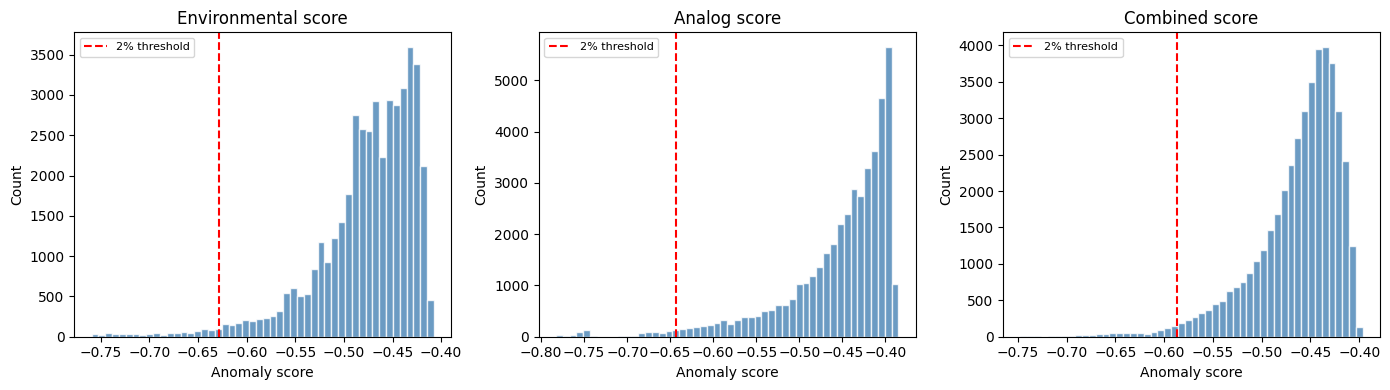

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (scores, title) in zip(axes, [
    (score_env,      'Environmental score'),
    (score_analog,   'Analog score'),
    (score_combined, 'Combined score'),
]):
    ax.hist(scores, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(np.percentile(scores, 2), color='red', linestyle='--', label='2% threshold')
    ax.set_title(title)
    ax.set_xlabel('Anomaly score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()

test single point

In [ ]:
temperature = 33.3
humidity    = 53.0
mic_level   = 630.0
mq2_raw     = 550.0


test_env    = scaler_env.transform([[temperature, humidity]])
test_analog = scaler_analog.transform([[mic_level, mq2_raw]])

s_env    = model_env.score_samples(test_env)[0]
s_analog = model_analog.score_samples(test_analog)[0]
s_comb   = w_env * s_env + w_analog * s_analog

label = "ANOMALY" if s_comb < threshold else "Normal"

print(f"Result            : {label}")
print(f"Env score         : {s_env:.4f}  (temp + humidity)")
print(f"Analog score      : {s_analog:.4f}  (mic + mq2)")
print(f"Combined score    : {s_comb:.4f}  (threshold = {threshold:.4f})")

Result            : Normal
Env score         : -0.4932  (temp + humidity)
Analog score      : -0.5016  (mic + mq2)
Combined score    : -0.4982  (threshold = -0.5870)


/home/farkhin/Enter/envs/AI_Showcase/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/farkhin/Enter/envs/AI_Showcase/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [79]:
env_features    = ['temperature', 'humidity']
analog_features = ['mic_level', 'mq2_raw']

explainer_env = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_env_scaled,
    feature_names         = env_features,
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

explainer_analog = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_analog_scaled,
    feature_names         = analog_features,
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

def predict_env(X):
    scores = model_env.score_samples(X)
    prob   = 1 - (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return np.column_stack([1 - prob, prob])

def predict_analog(X):
    scores = model_analog.score_samples(X)
    prob   = 1 - (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return np.column_stack([1 - prob, prob])

/home/farkhin/Enter/envs/AI_Showcase/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/farkhin/Enter/envs/AI_Showcase/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Result         : Normal
Combined score : -0.4982  (threshold = -0.5870)

── Environmental ─────────────────────────────────────────
   -0.61 < humidity <= 0.23            -0.1095  ↓ normal
   -0.20 < temperature <= 0.74         -0.0910  ↓ normal

── Analog ────────────────────────────────────────────────
   mic_level > 0.62                    +0.1628  ↑ anomaly
   mq2_raw <= -0.64                    +0.1282  ↑ anomaly


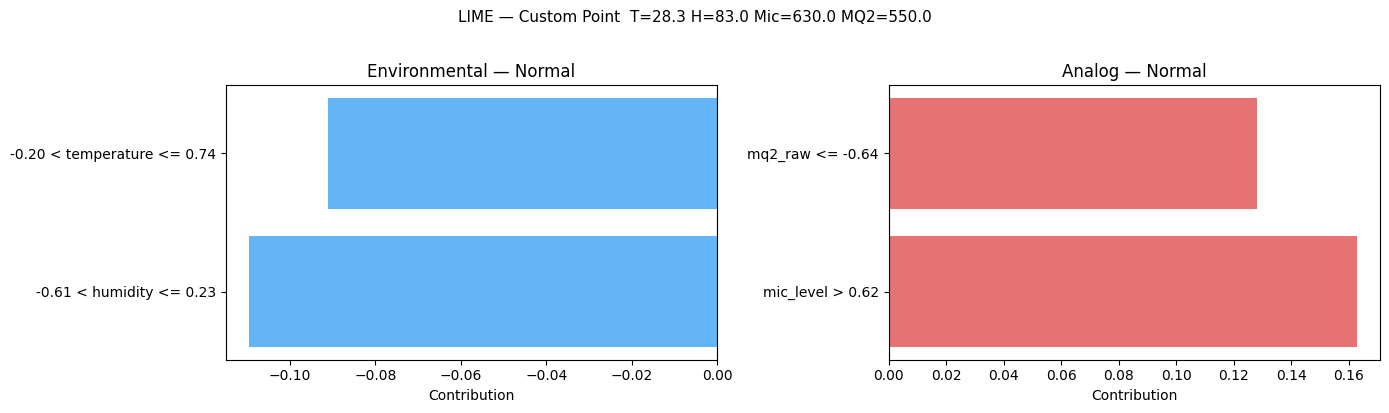

In [80]:
test_env    = scaler_env.transform([[temperature, humidity]])
test_analog = scaler_analog.transform([[mic_level, mq2_raw]])

exp_env_custom = explainer_env.explain_instance(
    data_row   = test_env[0],
    predict_fn = predict_env,
    num_features = len(env_features),
    num_samples  = 1000
)

exp_analog_custom = explainer_analog.explain_instance(
    data_row   = test_analog[0],
    predict_fn = predict_analog,
    num_features = len(analog_features),
    num_samples  = 1000
)

s_env    = model_env.score_samples(test_env)[0]
s_analog = model_analog.score_samples(test_analog)[0]
s_comb   = w_env * s_env + w_analog * s_analog
label    = "ANOMALY" if s_comb < threshold else "Normal"

print(f"Result         : {label}")
print(f"Combined score : {s_comb:.4f}  (threshold = {threshold:.4f})")
print()
print("── Environmental ─────────────────────────────────────────")
for feat, weight in exp_env_custom.as_list(label=1):
    print(f"   {feat:<35} {weight:+.4f}  {'↑ anomaly' if weight > 0 else '↓ normal'}")
print()
print("── Analog ────────────────────────────────────────────────")
for feat, weight in exp_analog_custom.as_list(label=1):
    print(f"   {feat:<35} {weight:+.4f}  {'↑ anomaly' if weight > 0 else '↓ normal'}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, exp, title in zip(axes,
    [exp_env_custom, exp_analog_custom],
    ['Environmental', 'Analog']
):
    feats   = [f for f, _ in exp.as_list(label=1)]
    weights = [w for _, w in exp.as_list(label=1)]
    colors  = ['#e57373' if w > 0 else '#64b5f6' for w in weights]
    ax.barh(feats, weights, color=colors)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_title(f'{title} — {label}')
    ax.set_xlabel('Contribution')

plt.suptitle(f'LIME — Custom Point  T={temperature} H={humidity} Mic={mic_level} MQ2={mq2_raw}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('lime_custom_point.png', dpi=150, bbox_inches='tight')
plt.show()

In [81]:
joblib.dump(model_env,    'model_env.pkl')
joblib.dump(model_analog, 'model_analog.pkl')
joblib.dump(scaler_env,   'scaler_env.pkl')
joblib.dump(scaler_analog,'scaler_analog.pkl')

np.save('threshold.npy', threshold)